# 02 — Hypothesis Testing

- **H0:** conversion rate is equal between ad and psa groups
- **H1:** conversion rate differs

Primary test: two-proportion z-test. Chi-square of independence run alongside
to show their equivalence (chi2 = z² on a 2×2 table). We report the
**confidence interval and effect size**, not just the p-value — and close
with a retrospective power analysis.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))
import pandas as pd

res = json.loads(open("../report/results.json").read())
p = res["primary"]
table = pd.DataFrame([
    ["Control (psa)", p["n_psa"], p["conv_psa"], f"{p['rate_b']:.4%}"],
    ["Treatment (ad)", p["n_ad"], p["conv_ad"], f"{p['rate_a']:.4%}"],
], columns=["Group", "Users", "Conversions", "Conversion rate"])
table

,Group,Users,Conversions,Conversion rate
0,Control (psa),23524,420,1.7854%
1,Treatment (ad),564577,14423,2.5547%


In [2]:
print(f"absolute lift: {p['abs_diff']:+.4%}")
print(f"relative lift: {p['rel_lift']:+.2%}")
print(f"z = {p['z_stat']:.2f}, p-value = {p['p_value']:.3g}")
print(f"95% CI on the difference: [{p['ci95_low']:+.4%}, {p['ci95_high']:+.4%}]")
print(f"chi-square = {p['chi2']:.1f} (= z² = {p['z_stat']**2:.1f}), p = {p['chi2_p']:.3g}")

absolute lift: +0.7692%
relative lift: +43.09%
z = 7.37, p-value = 0
95% CI on the difference: [+0.5951%, +0.9434%]
chi-square = 54.3 (= z² = 54.3), p = 1.71e-13


**When to use which:** the z-test gives a signed statistic (supports
one-sided alternatives) and a natural CI on the rate difference; chi-square
generalizes to >2 groups. On a 2×2 table they are the same test.

**Significance ≠ practical importance:** with 588k users even a trivial
difference would be "significant". The decision-relevant quantities are the
relative lift and its CI — here a large relative effect, so the distinction
is comfortable; always check it explicitly.

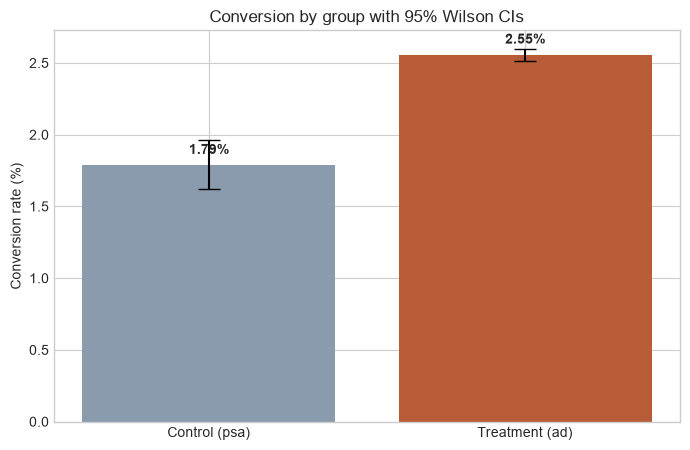

In [3]:
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
plt.style.use("seaborn-v0_8-whitegrid")

lo_a, hi_a = proportion_confint(p["conv_ad"], p["n_ad"], method="wilson")
lo_p, hi_p = proportion_confint(p["conv_psa"], p["n_psa"], method="wilson")
fig, ax = plt.subplots(figsize=(7, 4.6))
groups = ["Control (psa)", "Treatment (ad)"]
rates = [p["rate_b"] * 100, p["rate_a"] * 100]
errs = [[(p["rate_b"] - lo_p) * 100, (p["rate_a"] - lo_a) * 100],
        [(hi_p - p["rate_b"]) * 100, (hi_a - p["rate_a"]) * 100]]
ax.bar(groups, rates, yerr=errs, capsize=8, color=["#8A9BAE", "#B85C38"])
for i, v in enumerate(rates):
    ax.text(i, v + 0.08, f"{v:.2f}%", ha="center", fontweight="bold")
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Conversion by group with 95% Wilson CIs")
fig.tight_layout(); fig.savefig("figures/conversion_ci_chart.png", dpi=150)
plt.show()

## Retrospective power

In [4]:
pw = res["power"]
print(f"effect size (Cohen's h): {pw['effect_size_h']:.4f}")
print(f"power to detect the observed effect at alpha=0.05: {pw['power']:.3f}")
n_req = res["sample_size_10pct_mde"]
print(f"for reference, a 10% relative-lift MDE would need ~{n_req['n_per_group']:,} users per group")

effect size (Cohen's h): 0.0530
power to detect the observed effect at alpha=0.05: 1.000
for reference, a 10% relative-lift MDE would need ~90,537 users per group
